# 語言模型和數據集
:label:`sec_language_model`

在 :numref:`sec_text_preprocessing`中，
我們了解了如何將文本數據映射為詞元，
以及將這些詞元可以視為一系列離散的觀測，例如單詞或字符。
假設長度為$T$的文本序列中的詞元依次為$x_1, x_2, \ldots, x_T$。
於是，$x_t$（$1 \leq t \leq T$）
可以被認為是文本序列在時間步$t$處的觀測或標籤。
在給定這樣的文本序列時，*語言模型*（language model）的目標是估計序列的聯合概率

$$P(x_1, x_2, \ldots, x_T).$$

例如，只需要一次抽取一個詞元$x_t \sim P(x_t \mid x_{t-1}, \ldots, x_1)$，
一個理想的語言模型就能夠基於模型本身生成自然文本。
與猴子使用打字機完全不同的是，從這樣的模型中提取的文本
都將作為自然語言（例如，英語文本）來傳遞。
只需要基於前面的對話片斷中的文本，
就足以生成一個有意義的對話。
顯然，我們離設計出這樣的系統還很遙遠，
因為它需要“理解”文本，而僅僅是生成語法合理的內容。

儘管如此，語言模型依然是非常有用的。
例如，短語“to recognize speech”和“to wreck a nice beach”讀音上聽起來非常相似。
這種相似性會導致語音識別中的歧義，但是這很容易通過語言模型來解決，
因為第二句的語義很奇怪。
同樣，在文檔摘要生成算法中，
“狗咬人”比“人咬狗”出現的頻率要高得多，
或者“我想吃奶奶”是一個相當匪夷所思的語句，
而“我想吃，奶奶”則要正常得多。

## 學習語言模型

顯而易見，我們面對的問題是如何對一個文檔，
甚至是一個詞元序列進行建模。
假設在單詞級別對文本數據進行詞元化，
我們可以依靠在 :numref:`sec_sequence`中對序列模型的分析。
讓我們從基本概率規則開始：

$$P(x_1, x_2, \ldots, x_T) = \prod_{t=1}^T P(x_t  \mid  x_1, \ldots, x_{t-1}).$$

例如，包含了四個單詞的一個文本序列的概率是：

$$P(\text{deep}, \text{learning}, \text{is}, \text{fun}) =  P(\text{deep}) P(\text{learning}  \mid  \text{deep}) P(\text{is}  \mid  \text{deep}, \text{learning}) P(\text{fun}  \mid  \text{deep}, \text{learning}, \text{is}).$$

為了訓練語言模型，我們需要計算單詞的概率，
以及給定前面幾個單詞後出現某個單詞的條件概率。
這些概率本質上就是語言模型的參數。

這裡，我們假設訓練數據集是一個大型的文本語料庫。
比如，維基百科的所有條目、
[古登堡計劃](https://en.wikipedia.org/wiki/Project_Gutenberg)，
或者所有發布在網絡上的文本。
訓練數據集中詞的概率可以根據給定詞的相對詞頻來計算。
例如，可以將估計值$\hat{P}(\text{deep})$
計算為任何以單詞“deep”開頭的句子的概率。
一種（稍稍不太精確的）方法是統計單詞“deep”在數據集中的出現次數，
然後將其除以整個語料庫中的單詞總數。
這種方法效果不錯，特別是對於頻繁出現的單詞。
接下來，我們可以嘗試估計

$$\hat{P}(\text{learning} \mid \text{deep}) = \frac{n(\text{deep, learning})}{n(\text{deep})},$$

其中$n(x)$和$n(x, x')$分別是單個單詞和連續單詞對的出現次數。
不幸的是，由於連續單詞對“deep learning”的出現頻率要低得多，
所以估計這類單詞正確的概率要困難得多。
特別是對於一些不常見的單詞組合，要想找到足夠的出現次數來獲得準確的估計可能都不容易。
對於三個或者更多的單詞組合，情況會變得更糟。
許多合理的三個單詞組合可能是存在的，但是在數據集中卻找不到。
除非我們提供某種解決方案，來將這些單詞組合指定為非零計數，
否則將無法在語言模型中使用它們。
如果數據集很小，或者單詞非常罕見，那麼這類單詞出現一次的機會可能都找不到。

一種常見的策略是執行某種形式的*拉普拉斯平滑*（Laplace smoothing），
具體方法是在所有計數中添加一個小常量。
用$n$表示訓練集中的單詞總數，用$m$表示唯一單詞的數量。
此解決方案有助於處理單元素問題，例如通過：

$$
\begin{aligned}
    \hat{P}(x) & = \frac{n(x) + \epsilon_1/m}{n + \epsilon_1}, \\
    \hat{P}(x' \mid x) & = \frac{n(x, x') + \epsilon_2 \hat{P}(x')}{n(x) + \epsilon_2}, \\
    \hat{P}(x'' \mid x,x') & = \frac{n(x, x',x'') + \epsilon_3 \hat{P}(x'')}{n(x, x') + \epsilon_3}.
\end{aligned}
$$

其中，$\epsilon_1,\epsilon_2$和$\epsilon_3$是超參數。
以$\epsilon_1$為例：當$\epsilon_1 = 0$時，不應用平滑；
當$\epsilon_1$接近正無窮大時，$\hat{P}(x)$接近均勻概率分布$1/m$。
上面的公式是 :cite:`Wood.Gasthaus.Archambeau.ea.2011`
的一個相當原始的變形。

然而，這樣的模型很容易變得無效，原因如下：
首先，我們需要存儲所有的計數；
其次，這完全忽略了單詞的意思。
例如，“貓”（cat）和“貓科動物”（feline）可能出現在相關的上下文中，
但是想根據上下文調整這類模型其實是相當困難的。
最後，長單詞序列大部分是沒出現過的，
因此一個模型如果只是簡單地統計先前“看到”的單詞序列頻率，
那麼模型面對這種問題肯定是表現不佳的。

## 馬爾可夫模型與$n$元語法

在討論包含深度學習的解決方案之前，我們需要了解更多的概念和術語。
回想一下我們在 :numref:`sec_sequence`中對馬爾可夫模型的討論，
並將其應用於語言建模。
如果$P(x_{t+1} \mid x_t, \ldots, x_1) = P(x_{t+1} \mid x_t)$，
則序列上的分布滿足一階馬爾可夫性質。
階數越高，對應的依賴關係就越長。
這種性質推導出了許多可以應用於序列建模的近似公式：

$$
\begin{aligned}
P(x_1, x_2, x_3, x_4) &=  P(x_1) P(x_2) P(x_3) P(x_4),\\
P(x_1, x_2, x_3, x_4) &=  P(x_1) P(x_2  \mid  x_1) P(x_3  \mid  x_2) P(x_4  \mid  x_3),\\
P(x_1, x_2, x_3, x_4) &=  P(x_1) P(x_2  \mid  x_1) P(x_3  \mid  x_1, x_2) P(x_4  \mid  x_2, x_3).
\end{aligned}
$$

通常，涉及一個、兩個和三個變量的概率公式分別被稱為
*一元語法*（unigram）、*二元語法*（bigram）和*三元語法*（trigram）模型。
下面，我們將學習如何去設計更好的模型。

## 自然語言統計

我們看看在真實數據上如果進行自然語言統計。
根據 :numref:`sec_text_preprocessing`中介紹的時光機器數據集構建詞表，
並打印前$10$個最常用的（頻率最高的）單詞。


In [1]:
import random
import torch

In [4]:
!wget http://www.gutenberg.org/files/35/35-0.txt -O timemachine.txt

--2025-02-02 22:11:31--  http://www.gutenberg.org/files/35/35-0.txt
Resolving www.gutenberg.org (www.gutenberg.org)... 152.19.134.47, 2610:28:3090:3000:0:bad:cafe:47
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.gutenberg.org/files/35/35-0.txt [following]
--2025-02-02 22:11:31--  https://www.gutenberg.org/files/35/35-0.txt
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 204357 (200K) [text/plain]
Saving to: ‘timemachine.txt’

timemachine.txt     100%[===================>] 199.57K  --.-KB/s    in 0.1s    

2025-02-02 22:11:31 (1.84 MB/s) - ‘timemachine.txt’ saved [204357/204357]



In [5]:
import re
from collections import Counter
def read_time_machine(file_path='./timemachine.txt'): # Add file_path with default
        """Load the time machine dataset into a list of text lines."""
        with open(file_path, 'r') as f:  # Use file_path to open
            lines = f.readlines()
        return [re.sub('[^A-Za-z]+', ' ', line).strip().lower() for line in lines]


def tokenize(lines, token='word'):
  """Split text lines into word or character tokens."""
  if token == 'word':
    return [line.split() for line in lines]
  elif token == 'char':
    return [list(line) for line in lines]
  else:
    print('ERROR: unknown token type: ' + token)
class Vocab:
  """Vocabulary for text."""
  def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
    if tokens is None:
      tokens = []
    if reserved_tokens is None:
      reserved_tokens = []
    # Sort according to frequencies
    counter = Counter([token for line in tokens for token in line])
    self.token_freqs = sorted(counter.items(), key=lambda x: x[1],
                              reverse=True)
    # The index for the unknown token is 0
    self.idx_to_token = ['<unk>'] + reserved_tokens + [
        token for token, freq in self.token_freqs
        if freq >= min_freq and token not in reserved_tokens
    ]
    self.token_to_idx = {token: idx for idx, token in
                         enumerate(self.idx_to_token)}
tokens = tokenize(read_time_machine())
corpus = [token for line in tokens for token in line]
vocab = Vocab(corpus)
print(vocab.token_freqs[:10])

[('e', 19781), ('t', 15155), ('a', 12752), ('i', 11312), ('o', 11157), ('n', 11012), ('s', 9313), ('r', 8895), ('h', 8841), ('d', 6868)]


正如我們所看到的，(**最流行的詞**)看起來很無聊，
這些詞通常(**被稱為*停用詞***)（stop words），因此可以被過濾掉。
儘管如此，它們本身仍然是有意義的，我們仍然會在模型中使用它們。
此外，還有個明顯的問題是詞頻衰減的速度相當地快。
例如，最常用單詞的詞頻對比，第$10$個還不到第$1$個的$1/5$。
為了更好地理解，我們可以[**畫出的詞頻圖**]：


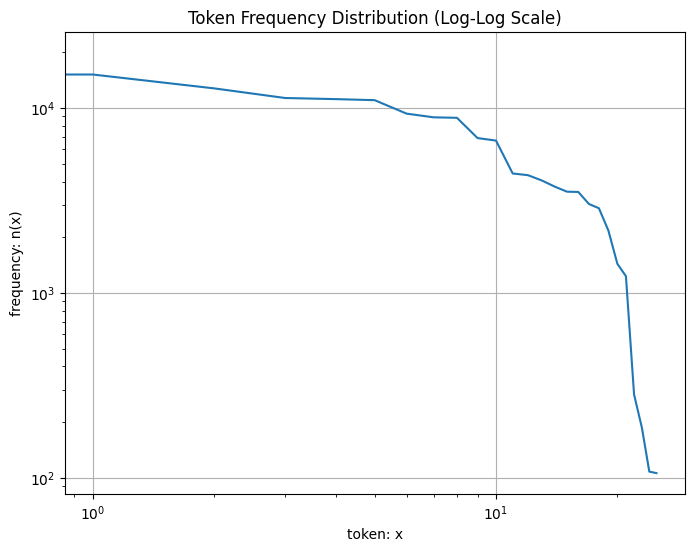

In [6]:
import matplotlib.pyplot as plt

freqs = [freq for token, freq in vocab.token_freqs]

# Plotting the frequencies on a log-log scale
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
plt.plot(freqs)
plt.xlabel('token: x')
plt.ylabel('frequency: n(x)')
plt.xscale('log')
plt.yscale('log')
plt.title('Token Frequency Distribution (Log-Log Scale)')
plt.grid(True)  # Add grid lines
plt.show()

通過此圖我們可以發現：詞頻以一種明確的方式迅速衰減。
將前幾個單詞作為例外消除後，剩餘的所有單詞大致遵循雙對數坐標圖上的一條直線。
這意味著單詞的頻率滿足*齊普夫定律*（Zipf's law），
即第$i$個最常用單詞的頻率$n_i$為：

$$n_i \propto \frac{1}{i^\alpha},$$
:eqlabel:`eq_zipf_law`

等價於

$$\log n_i = -\alpha \log i + c,$$

其中$\alpha$是刻畫分布的指數，$c$是常數。
這告訴我們想要通過計數統計和平滑來建模單詞是不可行的，
因為這樣建模的結果會大大高估尾部單詞的頻率，也就是所謂的不常用單詞。
那麼[**其他的詞元組合，比如二元語法、三元語法等等，又會如何呢？**]
我們來看看二元語法的頻率是否與一元語法的頻率表現出相同行為方式。


In [7]:
from collections import Counter

bigram_tokens = [pair for pair in zip(corpus[:-1], corpus[1:])]

# Create a Counter to count bigram frequencies
bigram_counter = Counter(bigram_tokens)

# Get the most common bigrams (equivalent to bigram_vocab.token_freqs[:10])
bigram_freqs = bigram_counter.most_common(10)

print(bigram_freqs)

[(('of', 'the'), 344), (('in', 'the'), 192), (('i', 'had'), 130), (('and', 'the'), 112), (('i', 'was'), 112), (('the', 'time'), 110), (('to', 'the'), 101), (('it', 'was'), 99), (('project', 'gutenberg'), 88), (('as', 'i'), 78)]


這裡值得注意：在十個最頻繁的詞對中，有九個是由兩個停用詞組成的，
只有一個與“the time”有關。
我們再進一步看看三元語法的頻率是否表現出相同行為方式。


In [9]:
from collections import Counter

trigram_tokens = [triple for triple in zip(corpus[:-2], corpus[1:-1], corpus[2:])]

# Create a Counter to count trigram frequencies
trigram_counter = Counter(trigram_tokens)

# Get the most common trigrams (equivalent to trigram_vocab.token_freqs[:10])
trigram_freqs = trigram_counter.most_common(10)

print(trigram_freqs)

[(('the', 'time', 'traveller'), 63), (('project', 'gutenberg', 'tm'), 57), (('the', 'time', 'machine'), 34), (('the', 'project', 'gutenberg'), 33), (('the', 'medical', 'man'), 24), (('gutenberg', 'tm', 'electronic'), 18), (('it', 'seemed', 'to'), 16), (('it', 'was', 'a'), 15), (('here', 'and', 'there'), 15), (('the', 'united', 'states'), 14)]


最後，我們[**直觀地對比三種模型中的詞元頻率**]：一元語法、二元語法和三元語法。


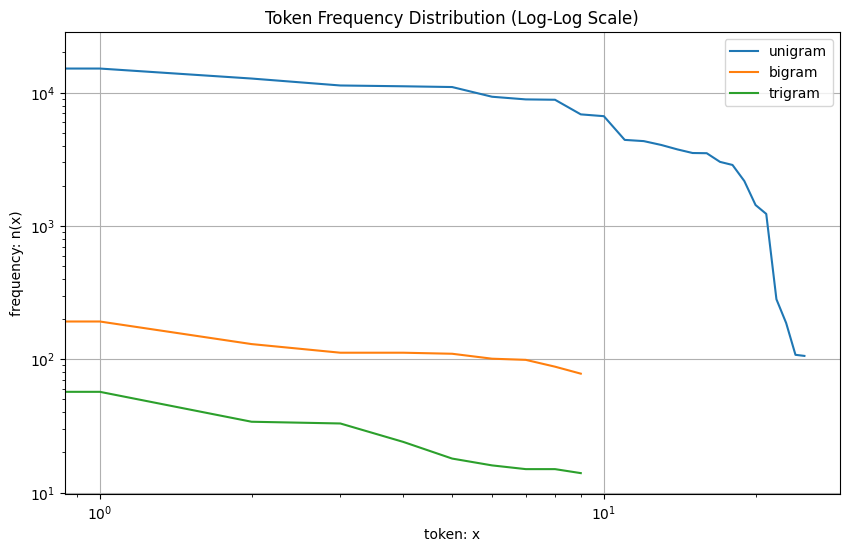

In [11]:
import matplotlib.pyplot as plt

# Assuming you have already calculated freqs, bigram_freqs, and trigram_freqs

plt.figure(figsize=(10, 6))  # Adjust figure size if needed

plt.plot(freqs, label='unigram')

# Extract only the frequencies from bigram_freqs and trigram_freqs:
bigram_freqs_values = [freq for token, freq in bigram_freqs]
trigram_freqs_values = [freq for token, freq in trigram_freqs]

plt.plot(bigram_freqs_values, label='bigram')
plt.plot(trigram_freqs_values, label='trigram')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('token: x')
plt.ylabel('frequency: n(x)')
plt.title('Token Frequency Distribution (Log-Log Scale)')
plt.legend()  # Display legend
plt.grid(True)
plt.show()

這張圖非常令人振奮！原因有很多：

1. 除了一元語法詞，單詞序列似乎也遵循齊普夫定律，
儘管公式 :eqref:`eq_zipf_law`中的指數$\alpha$更小
（指數的大小受序列長度的影響）；
2. 詞表中$n$元組的數量並沒有那麼大，這說明語言中存在相當多的結構，
這些結構給了我們應用模型的希望；
3. 很多$n$元組很少出現，這使得拉普拉斯平滑非常不適合語言建模。
作為代替，我們將使用基於深度學習的模型。

## 讀取長序列數據

由於序列數據本質上是連續的，因此我們在處理數據時需要解決這個問題。
在 :numref:`sec_sequence`中我們以一種相當特別的方式做到了這一點：
當序列變得太長而不能被模型一次性全部處理時，
我們可能希望拆分這樣的序列方便模型讀取。

在介紹該模型之前，我們看一下總體策略。
假設我們將使用神經網路來訓練語言模型，
模型中的網路一次處理具有預定義長度
（例如$n$個時間步）的一個小批量序列。
現在的問題是如何[**隨機生成一個小批量數據的特徵和標籤以供讀取。**]

首先，由於文本序列可以是任意長的，
例如整本《時光機器》（*The Time Machine*），
於是任意長的序列可以被我們劃分為具有相同時間步數的子序列。
當訓練我們的神經網路時，這樣的小批量子序列將被輸入到模型中。
假設網路一次只處理具有$n$個時間步的子序列。
 :numref:`fig_timemachine_5gram`畫出了
從原始文本序列獲得子序列的所有不同的方式，
其中$n=5$，並且每個時間步的詞元對應於一個字符。
請注意，因為我們可以選擇任意偏移量來指示初始位置，所以我們有相當大的自由度。

![分割文本時，不同的偏移量會導致不同的子序列](../img/timemachine-5gram.svg)
:label:`fig_timemachine_5gram`

因此，我們應該從 :numref:`fig_timemachine_5gram`中選擇哪一個呢？
事實上，他們都一樣的好。
然而，如果我們只選擇一個偏移量，
那麼用於訓練網路的、所有可能的子序列的覆蓋範圍將是有限的。
因此，我們可以從隨機偏移量開始劃分序列，
以同時獲得*覆蓋性*（coverage）和*隨機性*（randomness）。
下面，我們將描述如何實現*隨機采樣*（random sampling）和
*順序分區*（sequential partitioning）策略。

### 隨機采樣

(**在隨機采樣中，每個樣本都是在原始的長序列上任意捕獲的子序列。**)
在迭代過程中，來自兩個相鄰的、隨機的、小批量中的子序列不一定在原始序列上相鄰。
對於語言建模，目標是基於到目前為止我們看到的詞元來預測下一個詞元，
因此標籤是移位了一個詞元的原始序列。

下面的代碼每次可以從數據中隨機生成一個小批量。
在這裡，參數`batch_size`指定了每個小批量中子序列樣本的數目，
參數`num_steps`是每個子序列中預定義的時間步數。


In [12]:
def seq_data_iter_random(corpus, batch_size, num_steps):  #@save
    """使用隨機抽樣生成一個小批量子序列"""
    # 從隨機偏移量開始對序列進行分區，隨機範圍包括num_steps-1
    corpus = corpus[random.randint(0, num_steps - 1):]
    # 減去1，是因為我們需要考慮標籤
    num_subseqs = (len(corpus) - 1) // num_steps
    # 長度為num_steps的子序列的起始索引
    initial_indices = list(range(0, num_subseqs * num_steps, num_steps))
    # 在隨機抽樣的迭代過程中，
    # 來自兩個相鄰的、隨機的、小批量中的子序列不一定在原始序列上相鄰
    random.shuffle(initial_indices)

    def data(pos):
        # 返回從pos位置開始的長度為num_steps的序列
        return corpus[pos: pos + num_steps]

    num_batches = num_subseqs // batch_size
    for i in range(0, batch_size * num_batches, batch_size):
        # 在這裡，initial_indices包含子序列的隨機起始索引
        initial_indices_per_batch = initial_indices[i: i + batch_size]
        X = [data(j) for j in initial_indices_per_batch]
        Y = [data(j + 1) for j in initial_indices_per_batch]
        yield torch.tensor(X), torch.tensor(Y)

下面我們[**生成一個從$0$到$34$的序列**]。
假設批量大小為$2$，時間步數為$5$，這意味著可以生成
$\lfloor (35 - 1) / 5 \rfloor= 6$個“特徵－標籤”子序列對。
如果設置小批量大小為$2$，我們只能得到$3$個小批量。


In [13]:
my_seq = list(range(35))
for X, Y in seq_data_iter_random(my_seq, batch_size=2, num_steps=5):
    print('X: ', X, '\nY:', Y)

X:  tensor([[18, 19, 20, 21, 22],
        [13, 14, 15, 16, 17]]) 
Y: tensor([[19, 20, 21, 22, 23],
        [14, 15, 16, 17, 18]])
X:  tensor([[28, 29, 30, 31, 32],
        [23, 24, 25, 26, 27]]) 
Y: tensor([[29, 30, 31, 32, 33],
        [24, 25, 26, 27, 28]])
X:  tensor([[ 3,  4,  5,  6,  7],
        [ 8,  9, 10, 11, 12]]) 
Y: tensor([[ 4,  5,  6,  7,  8],
        [ 9, 10, 11, 12, 13]])


### 順序分區

在迭代過程中，除了對原始序列可以隨機抽樣外，
我們還可以[**保證兩個相鄰的小批量中的子序列在原始序列上也是相鄰的**]。
這種策略在基於小批量的迭代過程中保留了拆分的子序列的順序，因此稱為順序分區。


In [14]:
def seq_data_iter_sequential(corpus, batch_size, num_steps):  #@save
    """使用順序分區生成一個小批量子序列"""
    # 從隨機偏移量開始劃分序列
    offset = random.randint(0, num_steps)
    num_tokens = ((len(corpus) - offset - 1) // batch_size) * batch_size
    Xs = torch.tensor(corpus[offset: offset + num_tokens])
    Ys = torch.tensor(corpus[offset + 1: offset + 1 + num_tokens])
    Xs, Ys = Xs.reshape(batch_size, -1), Ys.reshape(batch_size, -1)
    num_batches = Xs.shape[1] // num_steps
    for i in range(0, num_steps * num_batches, num_steps):
        X = Xs[:, i: i + num_steps]
        Y = Ys[:, i: i + num_steps]
        yield X, Y

基於相同的設置，通過順序分區[**讀取每個小批量的子序列的特徵`X`和標籤`Y`**]。
通過將它們打印出來可以發現：
迭代期間來自兩個相鄰的小批量中的子序列在原始序列中確實是相鄰的。


In [15]:
for X, Y in seq_data_iter_sequential(my_seq, batch_size=2, num_steps=5):
    print('X: ', X, '\nY:', Y)

X:  tensor([[ 4,  5,  6,  7,  8],
        [19, 20, 21, 22, 23]]) 
Y: tensor([[ 5,  6,  7,  8,  9],
        [20, 21, 22, 23, 24]])
X:  tensor([[ 9, 10, 11, 12, 13],
        [24, 25, 26, 27, 28]]) 
Y: tensor([[10, 11, 12, 13, 14],
        [25, 26, 27, 28, 29]])
X:  tensor([[14, 15, 16, 17, 18],
        [29, 30, 31, 32, 33]]) 
Y: tensor([[15, 16, 17, 18, 19],
        [30, 31, 32, 33, 34]])


現在，我們[**將上面的兩個採樣函數包裝到一個類中**]，
以便稍後可以將其用作數據迭代器。


In [16]:
class SeqDataLoader:  #@save
    """加载序列数据的迭代器"""
    def __init__(self, batch_size, num_steps, use_random_iter, max_tokens):
        if use_random_iter:
            self.data_iter_fn = d2l.seq_data_iter_random
        else:
            self.data_iter_fn = d2l.seq_data_iter_sequential
        self.corpus, self.vocab = d2l.load_corpus_time_machine(max_tokens)
        self.batch_size, self.num_steps = batch_size, num_steps

    def __iter__(self):
        return self.data_iter_fn(self.corpus, self.batch_size, self.num_steps)

[**最後，我們定義了一個函數`load_data_time_machine`，
它同時返回數據迭代器和詞表**]，
因此可以與其他帶有`load_data`前綴的函數
（如 :numref:`sec_fashion_mnist`中定義的
`d2l.load_data_fashion_mnist`）類似地使用。


In [17]:
def load_data_time_machine(batch_size, num_steps,  #@save
                           use_random_iter=False, max_tokens=10000):
    """返回时光机器数据集的迭代器和词表"""
    data_iter = SeqDataLoader(
        batch_size, num_steps, use_random_iter, max_tokens)
    return data_iter, data_iter.vocab

## 小結

* 語言模型是自然語言處理的關鍵。
* $n$元語法通過截斷相關性，為處理長序列提供了一種實用的模型。
* 長序列存在一個問題：它們很少出現或者從不出現。
* 齊普夫定律支配著單詞的分布，這個分布不僅適用於一元語法，還適用於其他$n$元語法。
* 通過拉普拉斯平滑法可以有效地處理結構豐富而頻率不足的低頻詞詞組。
* 讀取長序列的主要方式是隨機採樣和順序分區。在迭代過程中，後者可以保證來自兩個相鄰的小批量中的子序列在原始序列上也是相鄰的。

## 練習

1. 假設訓練數據集中有$100,000$個單詞。一個四元語法需要存儲多少個詞頻和相鄰多詞頻率？
1. 我們如何對一系列對話建模？
1. 一元語法、二元語法和三元語法的齊普夫定律的指數是不一樣的，能想辦法估計嗎？
1. 想一想讀取長序列數據的其他方法？
1. 考慮一下我們用於讀取長序列的隨機偏移量。
    1. 為什麼隨機偏移量是個好主意？
    1. 它真的會在文檔的序列上實現完美的均勻分布嗎？
    1. 要怎麼做才能使分布更均勻？
1. 如果我們希望一個序列樣本是一個完整的句子，那麼這在小批量抽樣中會帶來怎樣的問題？如何解決？


[Discussions](https://discuss.d2l.ai/t/2097)
